# IMPACT OF DIFFERENTIATED ASSISTANCE ON REFUGEE HOUSEHOLD’S 

## objective
>To evaluate the effectiveness of the differentiated assistance model in supporting vulnerable households in Kakuma Refugee Camp and assess its impact on household well-being, including debt levels and food security.

## context
>In 2025, WFP and UNHCR introduced a Differentiated Assistance model in Kakuma Refugee Camp to provide food and cash based on household vulnerability. This project evaluates whether the model effectively supports vulnerable households or leads to debt and food insecurity.

## Notebook Structure
1. Mount Google Drive and Load Dataset
2. Inspect and clean data
3. Exploratory Data Analysis (EDA)
> - Assistance vs Household Outcomes Comparison
> - Category-wise Analysis
4. Insights and Recommendations


## 1.loading the data

In [2]:
# Importing necessary libraries
import pandas as pd

# Loading the dataset
df= pd.read_csv("data_set/kakuma_differentiated_assistance_synthetic_dataset.csv")

df.shape

(17602, 23)

## 2. inspect and clean Data

In [3]:
# chech missing values
df. isnull().sum()

Household_ID                    0
Vulnerability_Category          0
Household_Size                  0
Dependency_Ratio                0
Primary_Income_Source           0
Employment_Status               0
Monthly_Income                  0
Food_Assistance_Received        0
Cash_Assistance_Received        0
Total_Assistance_Value          0
Monthly_Expenditure             0
Current_Debt_Level              0
Debt_Status                     0
Food_Consumption_Score          0
Food_Security_Status            0
Head_of_Household_Gender        0
Head_of_Household_Age           0
Female_Headed_Household         0
Disability_In_Household         0
Chronic_Illness_In_Household    0
Elderly_Members_Count           0
Children_Under_5_Count          0
Years_In_Camp                   0
dtype: int64

In [4]:
# cheching the duplicated
df.duplicated().sum() 

np.int64(260)

In [5]:
# removing duplicates
df.drop_duplicates(inplace=True)

In [6]:
df.columns

Index(['Household_ID', 'Vulnerability_Category', 'Household_Size',
       'Dependency_Ratio', 'Primary_Income_Source', 'Employment_Status',
       'Monthly_Income', 'Food_Assistance_Received',
       'Cash_Assistance_Received', 'Total_Assistance_Value',
       'Monthly_Expenditure', 'Current_Debt_Level', 'Debt_Status',
       'Food_Consumption_Score', 'Food_Security_Status',
       'Head_of_Household_Gender', 'Head_of_Household_Age',
       'Female_Headed_Household', 'Disability_In_Household',
       'Chronic_Illness_In_Household', 'Elderly_Members_Count',
       'Children_Under_5_Count', 'Years_In_Camp'],
      dtype='object')

In [7]:
# cheaking the Numeric Columns
df[['Monthly_Income', 
    'Food_Assistance_Received', 
    'Cash_Assistance_Received', 
    'Head_of_Household_Age']]

,Monthly_Income,Food_Assistance_Received,Cash_Assistance_Received,Head_of_Household_Age
0,2733,3479,3677,58
1,7587,8130,8790,47
2,2503,3920,3237,39
3,9424,10914,10575,47
4,8359KES,9724,9458,58
...,...,...,...,...
17597,8028,9849,8983,45
17598,"1,677",2412,2912,77
17599,4390,6356,5357,45
17600,2537,4281,3267,71


In [8]:
# cleaning the Numeric Columns

def clean_numeric_str(val):
    val = str(val).replace(',', '').replace('KES', '').strip()
    try:
        return int(float(val))
    except:
        return None

df['Monthly_Income'] = df['Monthly_Income'].apply(clean_numeric_str)
df['Food_Assistance_Received'] = df['Food_Assistance_Received'].apply(clean_numeric_str)
df['Cash_Assistance_Received'] = df['Cash_Assistance_Received'].apply(clean_numeric_str)
df['Head_of_Household_Age'] = df['Head_of_Household_Age'].apply(clean_numeric_str)

In [9]:
df[['Monthly_Income', 
    'Food_Assistance_Received', 
    'Cash_Assistance_Received', 
    'Head_of_Household_Age']]

,Monthly_Income,Food_Assistance_Received,Cash_Assistance_Received,Head_of_Household_Age
0,2733.0,3479,3677,58.0
1,7587.0,8130,8790,47.0
2,2503.0,3920,3237,39.0
3,9424.0,10914,10575,47.0
4,8359.0,9724,9458,58.0
...,...,...,...,...
17597,8028.0,9849,8983,45.0
17598,1677.0,2412,2912,77.0
17599,4390.0,6356,5357,45.0
17600,2537.0,4281,3267,71.0


In [10]:
## chaeking the Primary_Income_Source
df['Primary_Income_Source']


0            business
1         agriculture
2                 aid
3         Agriculture
4                 aid
             ...     
17597    Casual Labor
17598        Business
17599     Agriculture
17600         Trading
17601         Trading
Name: Primary_Income_Source, Length: 17342, dtype: object

In [11]:
## Standardise Primary_Income_Source

df['Primary_Income_Source'] = df['Primary_Income_Source'].str.strip().str.title()
df['Primary_Income_Source'].unique()

array(['Business', 'Agriculture', 'Aid', 'Casual Labor', 'Trading'],
      dtype=object)

In [12]:
# cheacking the Employment_status
df['Employment_Status']


0        Self-Employed
1              employd
2         SelfEmployed
3              employd
4         SelfEmployed
             ...      
17597     SelfEmployed
17598          employd
17599     SelfEmployed
17600          employd
17601            unemp
Name: Employment_Status, Length: 17342, dtype: object

In [13]:
# Standardise Employment_Status and cleaning

emp_map = {
    'self-employed': 'Self-Employed',
    'selfemployed':  'Self-Employed',
    'employd':       'Employed',
    'employed':      'Employed',
    'unemp':         'Unemployed',
    'unemployed':    'Unemployed',
}
df['Employment_Status'] = (
    df['Employment_Status'].str.strip().str.lower().map(emp_map)
)

df['Employment_Status']

0        Self-Employed
1             Employed
2        Self-Employed
3             Employed
4        Self-Employed
             ...      
17597    Self-Employed
17598         Employed
17599    Self-Employed
17600         Employed
17601       Unemployed
Name: Employment_Status, Length: 17342, dtype: object

In [14]:
## cheaking Debt_status
df['Debt_Status']

0        Medium
1          High
2           Med
3        Medium
4          High
          ...  
17597       Low
17598        Lw
17599    Medium
17600      High
17601    Medium
Name: Debt_Status, Length: 17342, dtype: object

In [15]:
## Standardise Debt_Status and cleaning
debt_map = {
    'medium': 'Medium', 'med': 'Medium',
    'high':   'High',   'hgh': 'High',
    'low':    'Low',    'lw':  'Low',
}
df['Debt_Status'] = (
    df['Debt_Status'].str.strip().str.lower().map(debt_map)
)

df['Debt_Status']

0        Medium
1          High
2        Medium
3        Medium
4          High
          ...  
17597       Low
17598       Low
17599    Medium
17600      High
17601    Medium
Name: Debt_Status, Length: 17342, dtype: object

In [16]:
# cheaking the Food_Security_Status
df['Food_Security_Status']

0             Mod
1        Insecure
2         Insecur
3         Insecur
4        Insecure
           ...   
17597    Moderate
17598    Moderate
17599    Moderate
17600         Sec
17601         Sec
Name: Food_Security_Status, Length: 17342, dtype: object

In [17]:
# Standardise Food_Security_Status

fss_map = {
    'secure':   'Secure',   'sec':     'Secure',
    'moderate': 'Moderate', 'mod':     'Moderate',
    'insecure': 'Insecure', 'insecur': 'Insecure',
}
df['Food_Security_Status'] = (
    df['Food_Security_Status'].str.strip().str.lower().map(fss_map)
)

df['Food_Security_Status']

0        Moderate
1        Insecure
2        Insecure
3        Insecure
4        Insecure
           ...   
17597    Moderate
17598    Moderate
17599    Moderate
17600      Secure
17601      Secure
Name: Food_Security_Status, Length: 17342, dtype: object

In [18]:
## cheaking the Head_of_Household_Gender
df['Head_of_Household_Gender']

0        FEMALE
1             f
2          male
3          Male
4             M
          ...  
17597     Femal
17598    FEMALE
17599     Femal
17600      Male
17601         f
Name: Head_of_Household_Gender, Length: 17342, dtype: object

In [19]:
## Standardise Head_of_Household_Gender
def clean_gender(v):
    v = str(v).strip().lower()
    if v in ('female', 'f', 'femal'):
        return 'Female'
    elif v in ('male', 'm'):
        return 'Male'
    return v.title()

df['Head_of_Household_Gender'] = df['Head_of_Household_Gender'].apply(clean_gender)

df['Head_of_Household_Gender']

0        Female
1        Female
2          Male
3          Male
4          Male
          ...  
17597    Female
17598    Female
17599    Female
17600      Male
17601    Female
Name: Head_of_Household_Gender, Length: 17342, dtype: object

In [20]:
# cheaking the YES/NO 
##  Female_Headed_Household
## Disability_In_Household
## Chronic_Illness_In_Household
df['Female_Headed_Household'].unique()
df['Disability_In_Household'].unique()
df['Chronic_Illness_In_Household'].unique()

array(['No', 'N', 'Yes', 'Y', 'no', 'yes'], dtype=object)

In [21]:
# Standardise Yes/No Columns

yes_no_map = {'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No'}
for col in ['Female_Headed_Household', 'Disability_In_Household', 'Chronic_Illness_In_Household']:
    df[col] = df[col].str.strip().str.lower().map(yes_no_map)
    print(f"{col}: {df[col].unique()}")


Female_Headed_Household: ['No' 'Yes']
Disability_In_Household: ['No' 'Yes']
Chronic_Illness_In_Household: ['No' 'Yes']


## 3.Expolatory Data Analysis(EDA)

**3.1.	Household Distribution**
> **Question:** How many households are in each vulnerability category, and what % of total do they represent?

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Counting Households per Category

cat_counts = df['Vulnerability_Category'].value_counts().sort_index()

In [24]:
# Calculating Percentages

cat_pct = (cat_counts / len(df) * 100).round(2)

In [25]:
# Creating a Summary Table

summary_q1 = pd.DataFrame({
    'Households': cat_counts,
    'Percentage (%)': cat_pct
})
print(summary_q1.to_string())

                        Households  Percentage (%)
Vulnerability_Category                            
1                             4234           24.41
2                             4401           25.38
3                             4287           24.72
4                             4420           25.49


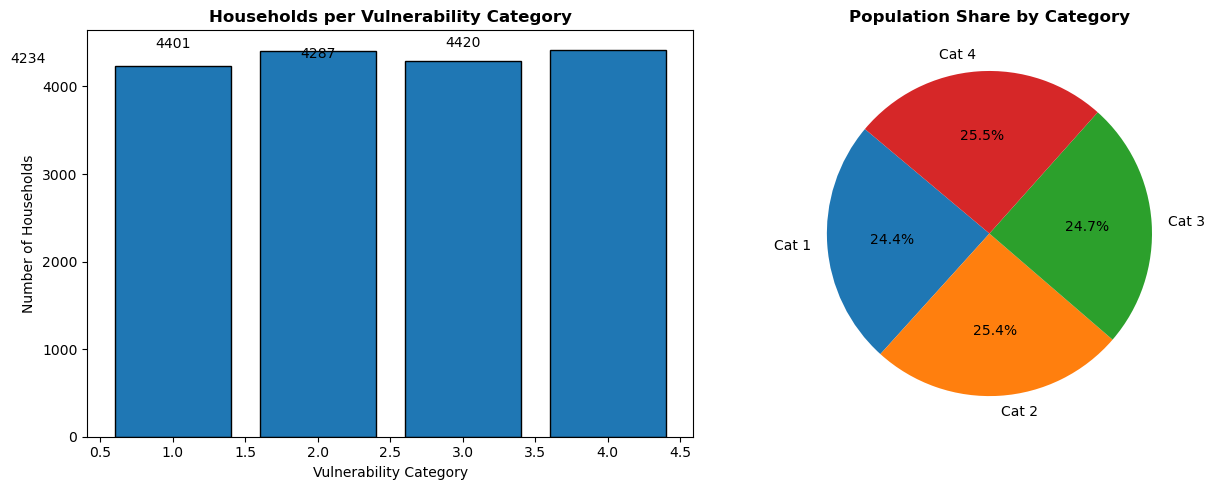

In [26]:
# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------
# Bar Chart
# -------------------------
axes[0].bar(cat_counts.index, 
            cat_counts.values,
            edgecolor='black')

axes[0].set_title('Households per Vulnerability Category', fontweight='bold')
axes[0].set_xlabel('Vulnerability Category')
axes[0].set_ylabel('Number of Households')

# Add values on top of bars
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# -------------------------
# Pie Chart
# -------------------------
axes[1].pie(cat_pct.values,
            labels=[f'Cat {c}' for c in cat_pct.index],
            autopct='%1.1f%%',
            startangle=140)

axes[1].set_title('Population Share by Category', fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()

## 3.2. Assistance Distribution
> **Quesrion:** Average food, cash, and total assistance per vulnerability category

In [27]:
assist_cols = ['Food_Assistance_Received', 'Cash_Assistance_Received', 'Total_Assistance_Value']
assist_avg  = df.groupby('Vulnerability_Category')[assist_cols].mean().round(1)
print(assist_avg.to_string())

                        Food_Assistance_Received  Cash_Assistance_Received  Total_Assistance_Value
Vulnerability_Category                                                                            
1                                         2757.3                    2395.8                  5153.1
2                                         4288.7                    3928.7                  8217.4
3                                         6257.6                    5909.6                 12167.2
4                                         8751.7                    8413.1                 17164.8


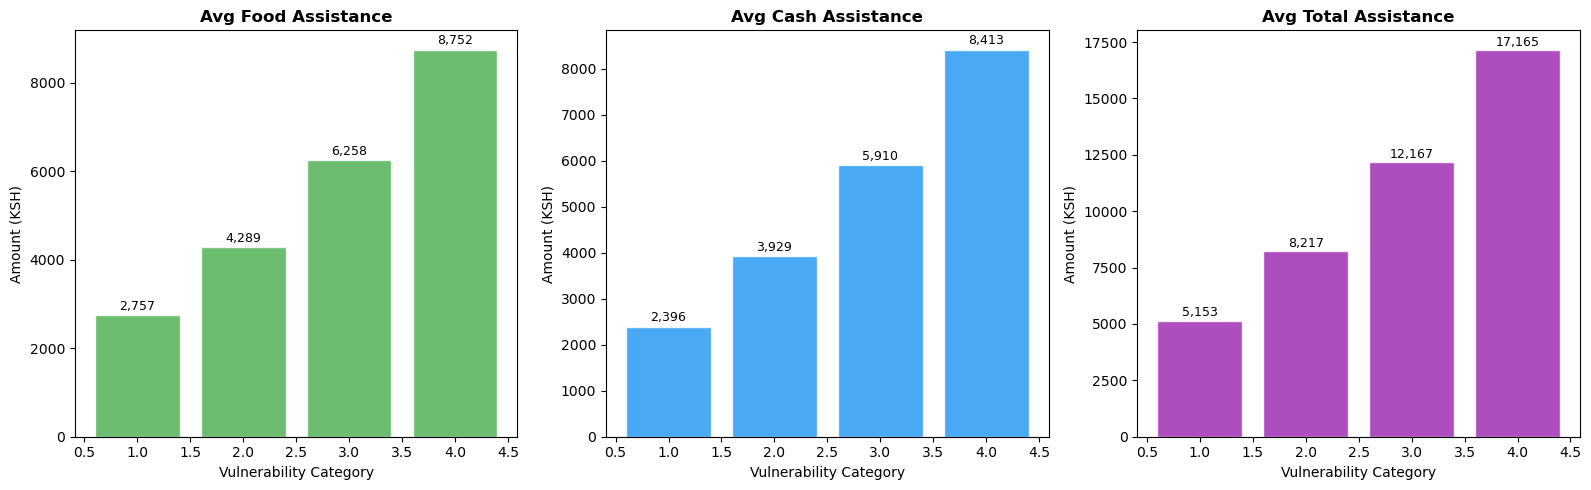

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles     = ['Avg Food Assistance', 'Avg Cash Assistance', 'Avg Total Assistance']

for ax, col, title, color in zip(axes, assist_cols, titles, ['#4CAF50', '#2196F3', '#9C27B0']):
    cats = assist_avg.index
    vals = assist_avg[col].values
    bars = ax.bar(cats, vals, color=color, alpha=0.82, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Vulnerability Category')
    ax.set_ylabel('Amount (KSH)')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

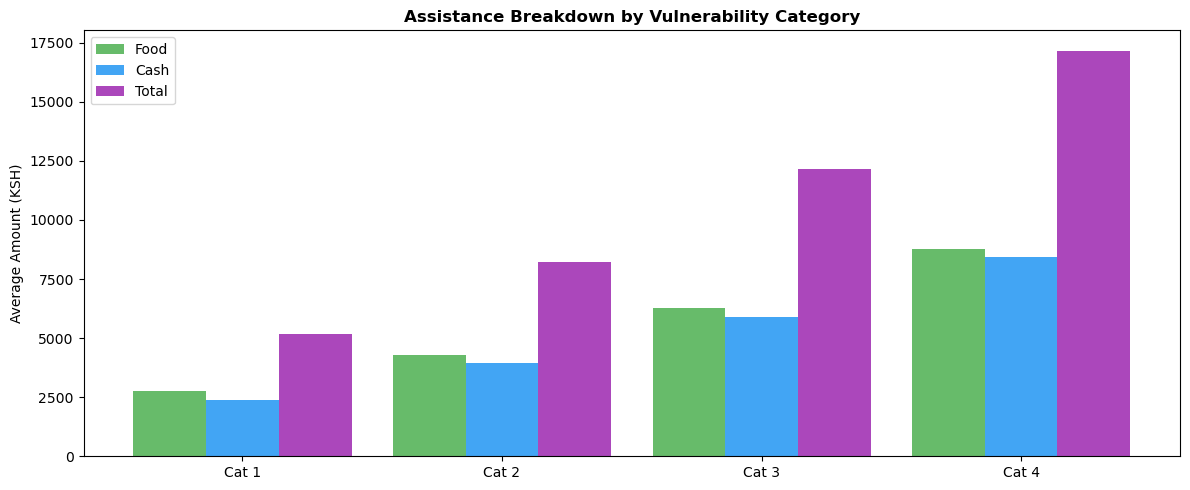

In [29]:
# Grouped bar
x       = np.arange(len(assist_avg))
width   = 0.28
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, assist_avg['Food_Assistance_Received'],  width, label='Food',  color='#4CAF50', alpha=0.85)
ax.bar(x,          assist_avg['Cash_Assistance_Received'],  width, label='Cash',  color='#2196F3', alpha=0.85)
ax.bar(x + width,  assist_avg['Total_Assistance_Value'],    width, label='Total', color='#9C27B0', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Cat {c}' for c in assist_avg.index])
ax.set_title('Assistance Breakdown by Vulnerability Category', fontweight='bold')
ax.set_ylabel('Average Amount (KSH)')
ax.legend()
plt.tight_layout()
plt.show()



## 3.3. Income and Expenditure
> **Question:**
> Distribution of monthly income · How expenditure compares to total assistance


In [30]:
print('Monthly Income — Summary Statistics')
print(df['Monthly_Income'].describe().round(1).to_string())

Monthly Income — Summary Statistics
count    16881.0
mean      4288.1
std       2555.2
min       -449.0
25%       2191.0
50%       4045.0
75%       6140.0
max      10472.0


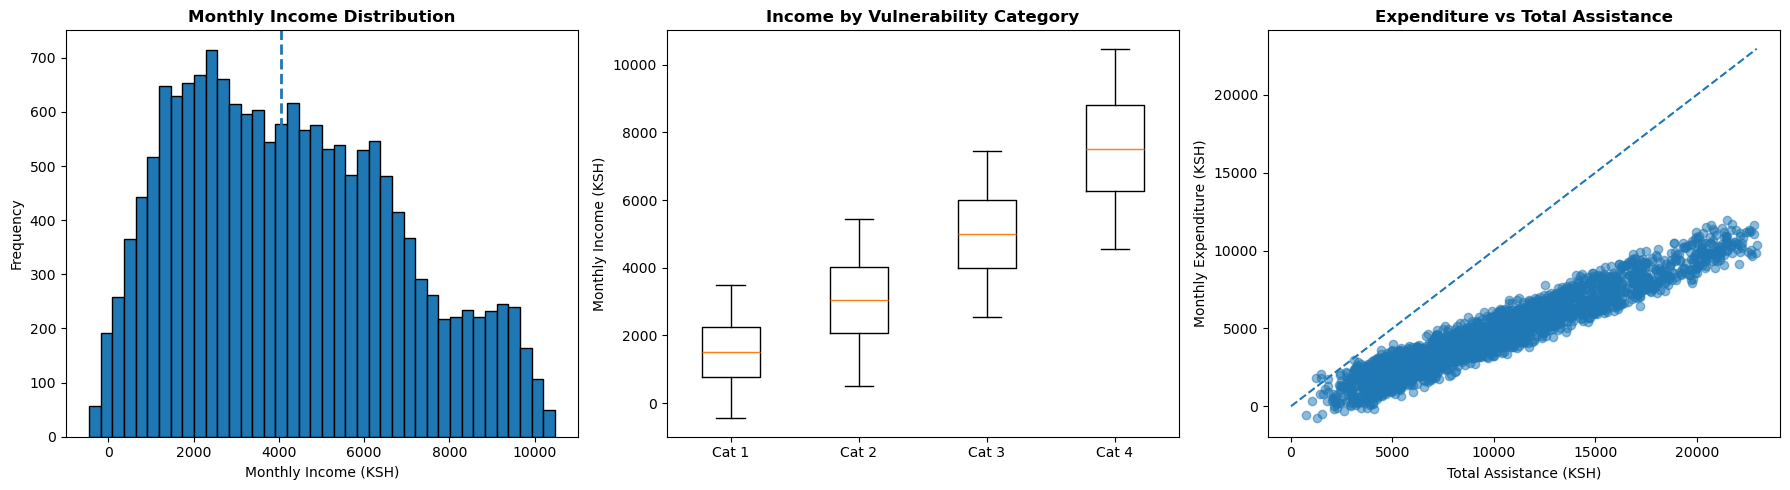

In [31]:

# income variable is defined
income = df['Monthly_Income'].dropna()

# Get categories
categories = sorted(df['Vulnerability_Category'].dropna().unique())

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =====================================================
# Histogram
# =====================================================
axes[0].hist(income, bins=40, edgecolor='black')

median_income = income.median()
axes[0].axvline(median_income, linestyle='--', linewidth=2)

axes[0].set_title('Monthly Income Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Income (KSH)')
axes[0].set_ylabel('Frequency')

# =====================================================
# Boxplot
# =====================================================
data_by_category = [
    df[df['Vulnerability_Category'] == c]['Monthly_Income'].dropna()
    for c in categories
]

axes[1].boxplot(data_by_category)
axes[1].set_xticklabels([f'Cat {int(c)}' for c in categories])
axes[1].set_title('Income by Vulnerability Category', fontweight='bold')
axes[1].set_ylabel('Monthly Income (KSH)')

# =====================================================
# Scatter Plot
# =====================================================
sample = df.sample(min(2000, len(df)), random_state=42)

axes[2].scatter(
    sample['Total_Assistance_Value'],
    sample['Monthly_Expenditure'],
    alpha=0.5
)

max_value = max(sample['Total_Assistance_Value'].max(),
                sample['Monthly_Expenditure'].max())

axes[2].plot([0, max_value], [0, max_value], linestyle='--')

axes[2].set_title('Expenditure vs Total Assistance', fontweight='bold')
axes[2].set_xlabel('Total Assistance (KSH)')
axes[2].set_ylabel('Monthly Expenditure (KSH)')

plt.tight_layout()
plt.show()

## 3.4. Debt Analysis

> **Questions:**  Average debt per category · % of households with high debt

In [32]:
avg_debt = df.groupby('Vulnerability_Category')['Current_Debt_Level'].mean().round(1)
print('Average Debt by Category:')
print(avg_debt.to_string())

Average Debt by Category:
Vulnerability_Category
1    5063.9
2    5118.4
3    5132.0
4    5061.1


In [33]:
high_debt_pct = (
    df[df['Debt_Status'] == 'High']
    .groupby('Vulnerability_Category').size()
    / df.groupby('Vulnerability_Category').size() * 100
).round(1)
print('\n% Households with High Debt:')
print(high_debt_pct.to_string())


% Households with High Debt:
Vulnerability_Category
1    32.9
2    34.5
3    33.2
4    32.5


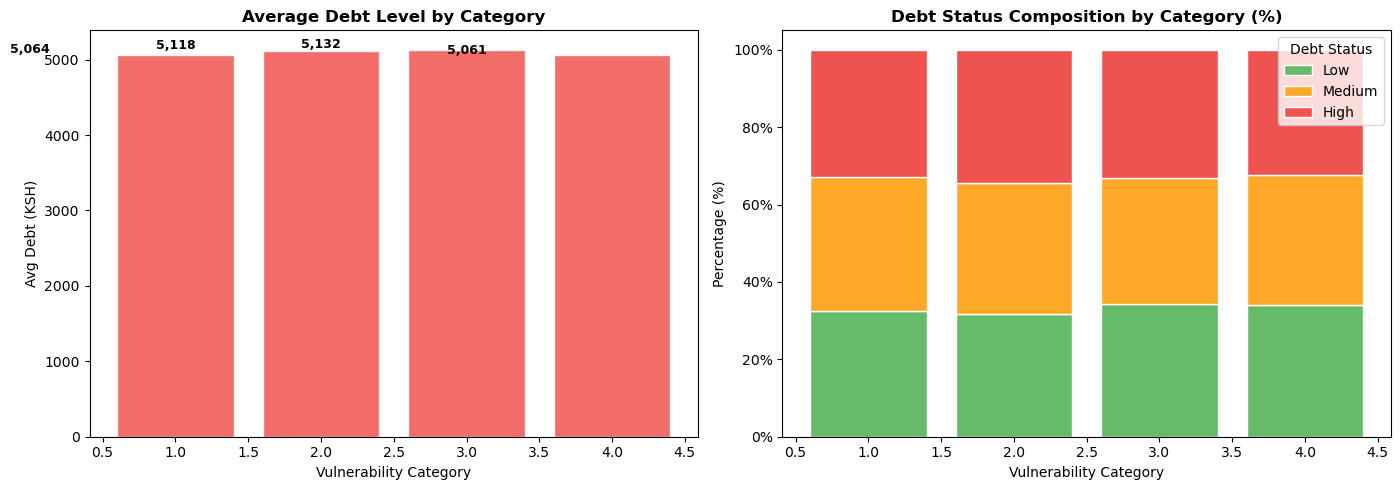

In [34]:


# Stacked bar: debt status composition
debt_comp = (
    df.groupby(['Vulnerability_Category', 'Debt_Status'])
    .size().unstack(fill_value=0)
)
debt_comp_pct = debt_comp.div(debt_comp.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(avg_debt.index, avg_debt.values, color='#EF5350', alpha=0.85, edgecolor='white')
for i, v in enumerate(avg_debt.values):
    axes[0].text(i, v + 20, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Average Debt Level by Category', fontweight='bold')
axes[0].set_xlabel('Vulnerability Category')
axes[0].set_ylabel('Avg Debt (KSH)')

colors_debt = {'Low': '#66BB6A', 'Medium': '#FFA726', 'High': '#EF5350'}
bottom = np.zeros(len(debt_comp_pct))
for status in ['Low', 'Medium', 'High']:
    if status in debt_comp_pct.columns:
        vals = debt_comp_pct[status].values
        axes[1].bar(debt_comp_pct.index, vals, bottom=bottom,
                    label=status, color=colors_debt[status], edgecolor='white')
        bottom += vals
axes[1].set_title('Debt Status Composition by Category (%)', fontweight='bold')
axes[1].set_xlabel('Vulnerability Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Debt Status')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 3.5.Food Security
> **Question** Food Consumption Scores across categories · Risk of food insecurity

Food Consumption Score by Category:
                         count   mean    std    min    25%    50%    75%     max
Vulnerability_Category                                                          
1                       4234.0  16.06  11.79   0.00   6.11  15.23  24.59   60.94
2                       4401.0  30.41  15.07   0.00  19.44  30.18  41.09   74.99
3                       4287.0  50.18  15.49   0.00  39.14  50.26  61.32   98.65
4                       4420.0  74.52  16.80  20.34  61.94  75.22  87.91  100.00

% Insecure Households by Category:
Vulnerability_Category
1    34.1
2    33.9
3    32.9
4    33.0


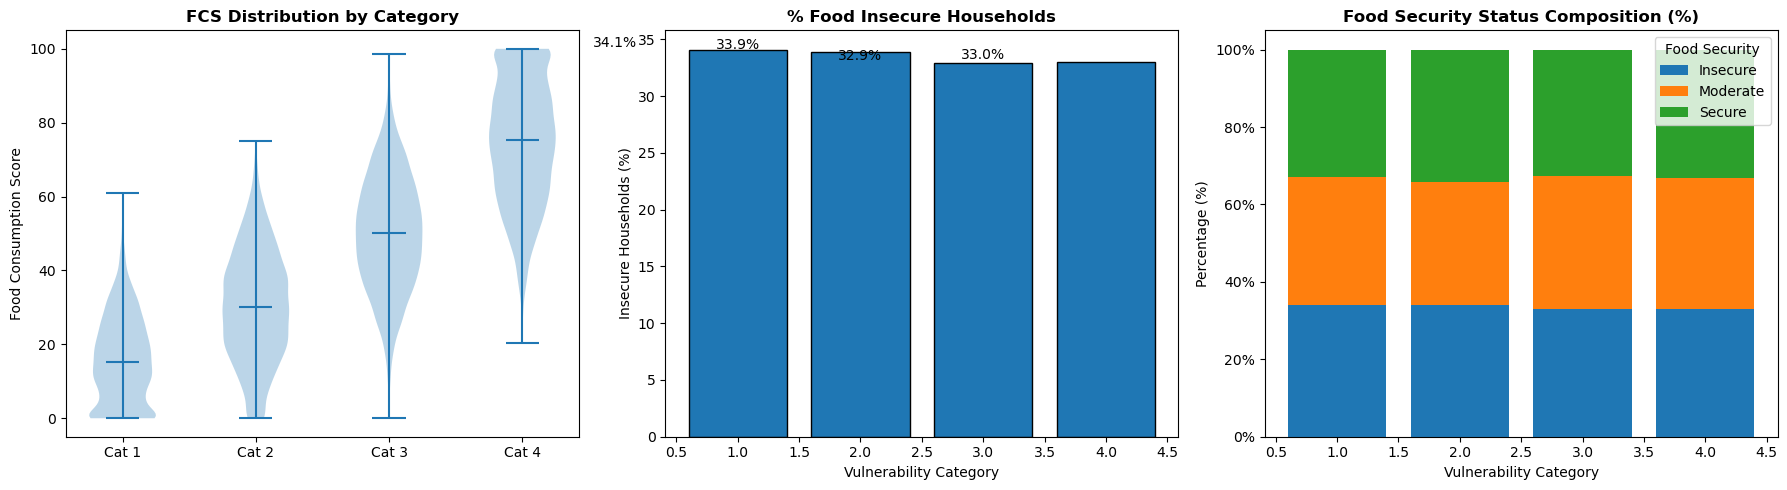

In [35]:
# ==============================
# Summary Tables
# ==============================
print('Food Consumption Score by Category:')
print(
    df.groupby('Vulnerability_Category')['Food_Consumption_Score']
      .describe()
      .round(2)
      .to_string()
)

# % Insecure households
insecure_pct = (
    df[df['Food_Security_Status'] == 'Insecure']
    .groupby('Vulnerability_Category')
    .size()
    / df.groupby('Vulnerability_Category').size() * 100
).round(1)

print('\n% Insecure Households by Category:')
print(insecure_pct.to_string())

# ==============================
# Create Figure
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==============================
# Chart 1: Violin Plot (FCS)
# ==============================
cats = sorted(df['Vulnerability_Category'].dropna().unique())

data_fcs = [
    df[df['Vulnerability_Category'] == c]['Food_Consumption_Score'].dropna()
    for c in cats
]

vp = axes[0].violinplot(data_fcs, positions=range(len(cats)), showmedians=True)

axes[0].set_xticks(range(len(cats)))
axes[0].set_xticklabels([f'Cat {int(c)}' for c in cats])
axes[0].set_title('FCS Distribution by Category', fontweight='bold')
axes[0].set_ylabel('Food Consumption Score')

# ==============================
# Chart 2: % Insecure Bar Chart
# ==============================
axes[1].bar(insecure_pct.index, insecure_pct.values, edgecolor='black')

for i, v in enumerate(insecure_pct.values):
    axes[1].text(i, v, f'{v}%', ha='center', va='bottom')

axes[1].set_title('% Food Insecure Households', fontweight='bold')
axes[1].set_xlabel('Vulnerability Category')
axes[1].set_ylabel('Insecure Households (%)')

# ==============================
# Chart 3: Stacked Bar Chart
# ==============================
fs_comp = (
    df.groupby(['Vulnerability_Category', 'Food_Security_Status'])
      .size()
      .unstack(fill_value=0)
)

fs_comp_pct = fs_comp.div(fs_comp.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(fs_comp_pct))

for status in fs_comp_pct.columns:
    vals = fs_comp_pct[status].values
    axes[2].bar(fs_comp_pct.index, vals, bottom=bottom, label=status)
    bottom += vals

axes[2].set_title('Food Security Status Composition (%)', fontweight='bold')
axes[2].set_xlabel('Vulnerability Category')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(title='Food Security')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

# ==============================
plt.tight_layout()
plt.show()

## 3.6 Assistance vs Outcomes
>**Questions:** Correlation of total assistance with debt level and food consumption score

Pearson Correlation (r)
• Assistance vs Debt Level: 0.0031
• Assistance vs Food Consumption Score: 0.9272


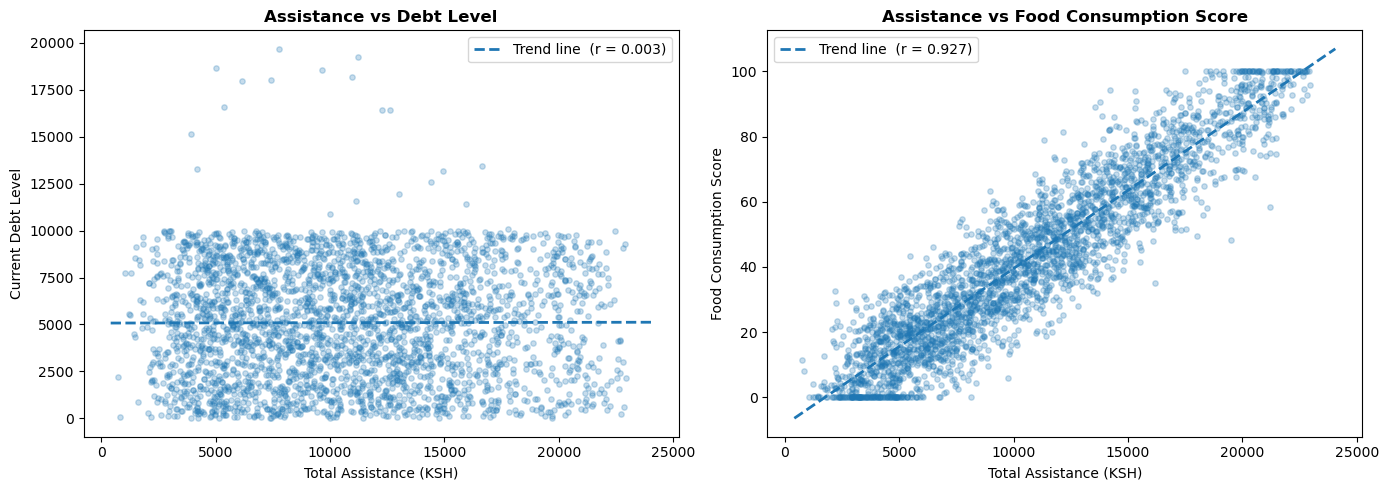

In [36]:

# ==========================================
# Correlation Calculation (Clean Method)
# ==========================================
corr_debt = df[['Total_Assistance_Value', 'Current_Debt_Level']].dropna().corr().iloc[0, 1]
corr_fcs  = df[['Total_Assistance_Value', 'Food_Consumption_Score']].dropna().corr().iloc[0, 1]

print(f'Pearson Correlation (r)')
print(f'• Assistance vs Debt Level: {corr_debt:.4f}')
print(f'• Assistance vs Food Consumption Score: {corr_fcs:.4f}')

# ==========================================
# Scatter Plots with Trend Lines
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample for performance
sample = df.sample(min(3000, len(df)), random_state=42)

plots = [
    ('Current_Debt_Level', 'Assistance vs Debt Level', corr_debt),
    ('Food_Consumption_Score', 'Assistance vs Food Consumption Score', corr_fcs)
]

for ax, (y_col, title, r) in zip(axes, plots):
    
    # Clean paired data for regression
    clean_data = df[['Total_Assistance_Value', y_col]].dropna()
    x = clean_data['Total_Assistance_Value']
    y = clean_data[y_col]
    
    # Scatter (sampled)
    ax.scatter(sample['Total_Assistance_Value'],
               sample[y_col],
               alpha=0.25, s=15)
    
    # Trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 300)
    ax.plot(x_line, m * x_line + b, linestyle='--', linewidth=2,
            label=f'Trend line  (r = {r:.3f})')
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Total Assistance (KSH)')
    ax.set_ylabel(y_col.replace('_', ' '))
    ax.legend()

plt.tight_layout()
plt.show()

## 8.At-Risk Identification
> **Question:** Highest combined risk of debt + food insecurity · Outliers in income, debt, and assistance

Outliers in Monthly_Income: 0 (0.0%)
Outliers in Current_Debt_Level: 97 (0.6%)
Outliers in Total_Assistance_Value: 0 (0.0%)


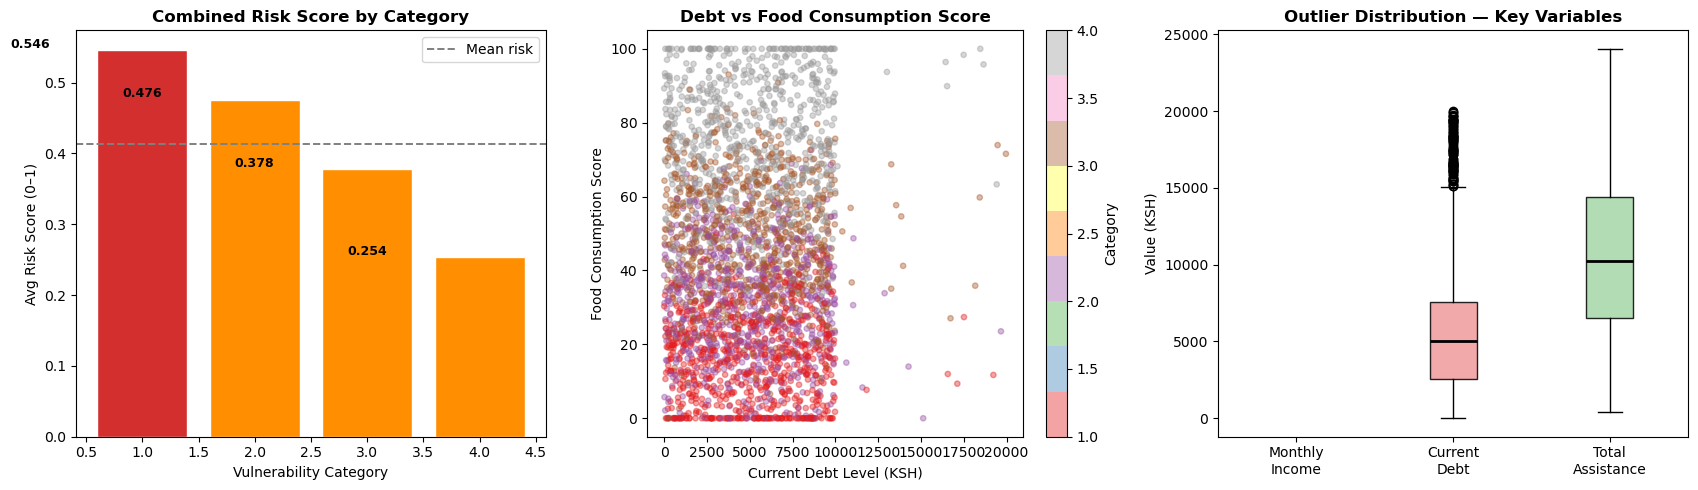

In [39]:
#=============== Combined risk score====================
from sklearn.preprocessing import MinMaxScaler

risk_df = df[['Vulnerability_Category', 'Current_Debt_Level', 'Food_Consumption_Score']].dropna().copy()

scaler = MinMaxScaler()
risk_df['Debt_Score'] = scaler.fit_transform(risk_df[['Current_Debt_Level']])
# FCS is inverted: lower score = higher food insecurity risk
risk_df['FCS_Risk']   = 1 - scaler.fit_transform(risk_df[['Food_Consumption_Score']])
risk_df['Risk_Score'] = (risk_df['Debt_Score'] + risk_df['FCS_Risk']) / 2

risk_by_cat = risk_df.groupby('Vulnerability_Category')['Risk_Score'].mean().round(4).sort_values(ascending=False)


# =================== Outlier detection (IQR method)=========================
def flag_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

for col in ['Monthly_Income', 'Current_Debt_Level', 'Total_Assistance_Value']:
    mask = flag_outliers(df[col])
    print(f'Outliers in {col}: {mask.sum():,} ({mask.mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Risk score bar
colors_risk = ['#D32F2F' if v == risk_by_cat.max() else '#FF8F00' for v in risk_by_cat.values]
axes[0].bar(risk_by_cat.index, risk_by_cat.values, color=colors_risk, edgecolor='white')
for i, v in enumerate(risk_by_cat.values):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Combined Risk Score by Category', fontweight='bold')
axes[0].set_xlabel('Vulnerability Category')
axes[0].set_ylabel('Avg Risk Score (0–1)')
axes[0].axhline(risk_by_cat.mean(), linestyle='--', color='grey', lw=1.4, label='Mean risk')
axes[0].legend()

# Scatter debt vs FCS coloured by category
sample2 = df.sample(min(3000, len(df)), random_state=99)
sc2 = axes[1].scatter(sample2['Current_Debt_Level'], sample2['Food_Consumption_Score'],
                      c=sample2['Vulnerability_Category'].astype(float),
                      cmap='Set1', alpha=0.4, s=15)
plt.colorbar(sc2, ax=axes[1], label='Category')
axes[1].set_title('Debt vs Food Consumption Score', fontweight='bold')
axes[1].set_xlabel('Current Debt Level (KSH)')
axes[1].set_ylabel('Food Consumption Score')

# Box plots for outlier visualisation
outlier_data = [df['Monthly_Income'], df['Current_Debt_Level'], df['Total_Assistance_Value']]
outlier_lbls = ['Monthly\nIncome', 'Current\nDebt', 'Total\nAssistance']
bp2 = axes[2].boxplot(outlier_data, patch_artist=True, notch=False,
                       medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp2['boxes'], ['#4FC3F7', '#EF9A9A', '#A5D6A7']):
    patch.set_facecolor(col); patch.set_alpha(0.85)
axes[2].set_xticklabels(outlier_lbls)
axes[2].set_title('Outlier Distribution — Key Variables', fontweight='bold')
axes[2].set_ylabel('Value (KSH)')

plt.tight_layout()
plt.show()